# 04 - What the detector actually does

**Question this notebook answers.** Across three versions of the detector on the same 218 servers, what detection rate is achieved and at what false-positive cost?

**Reads.** `data/processed/pilot_*.json`

Run top to bottom. Every number below is computed from the raw file named above; nothing is hard-coded.

In [1]:
import json, sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "notebooks"))
sys.path.insert(0, str(ROOT / "src"))
import matplotlib.pyplot as plt
import nbstyle
from nbstyle import BLUE, ORANGE, AQUA, ORDINAL, INK, INK_2, MUTED, CRITICAL
nbstyle.use_style()
PROC = ROOT / "data" / "processed"
RESULTS = ROOT / "results"

def load(name):
    p = PROC / name
    if not p.exists():
        raise FileNotFoundError(
            f"{p} is missing. Raw traces are gitignored; regenerate with the "
            f"command in results/README.md.")
    return json.loads(p.read_text(encoding="utf-8"))

print("reading from", PROC)

reading from F:\UIU\12th\CS\Paper work\repo\data\processed


**Definitions, chosen so a detection cannot be an artifact.**

- *landed* -- the tampering proxy reports it actually diverted something. Trials where no attack occurred are excluded.
- *detection* -- the attack landed, the tampered trial fired, **and the honest trial on the same server stayed silent**. The honest cross-check is what separates a real catch from a broken relation firing on everything.
- *FPR* -- the honest trial fired at all, over every usable server.

In [2]:
RUNS = [("pre-R7 baseline",  "pilot_pre_r7_baseline.json"),
        ("R7 uncalibrated",  "pilot_r7.json"),
        ("R7 calibrated",    "pilot_r7_calibrated.json")]

def honest(r):   return r.get("honest", {}).get("alerts", []) or []
def tampered(r):
    t = r.get("tampered", {})
    return t.get("L1", t) if isinstance(t, dict) else {}

def fired(alerts, permissive):
    sev = ("[VIOLATION]", "[WARNING]") if permissive else ("[VIOLATION]",)
    return any(a.startswith(s) for a in alerts for s in sev)

def point(rows, permissive):
    landed = [r for r in rows if tampered(r).get("attack_landed")]
    tp = [r for r in landed if fired(tampered(r).get("alerts", []), permissive)
          and not fired(honest(r), permissive)]
    fp = [r for r in rows if fired(honest(r), permissive)]
    return (len(landed), len(tp), len(fp),
            len(tp)/len(landed) if landed else 0.0,
            len(fp)/len(rows) if rows else 0.0)

table = []
for label, fname in RUNS:
    rows = [r for r in load(fname) if r.get("status") == "ok"]
    for perm, pname in ((False, "strict"), (True, "permissive")):
        landed, tp, fp, det, fpr = point(rows, perm)
        table.append((label, pname, len(rows), landed, tp, det, fp, fpr))
        print(f"{label:<18} {pname:<11} n={len(rows):>4} landed={landed:>4} "
              f"TP={tp:>3} det={100*det:>5.1f}%  FP={fp:>4} FPR={100*fpr:>5.1f}%")

pre-R7 baseline    strict      n= 217 landed= 205 TP=  0 det=  0.0%  FP=   4 FPR=  1.8%
pre-R7 baseline    permissive  n= 217 landed= 205 TP=  5 det=  2.4%  FP= 170 FPR= 78.3%
R7 uncalibrated    strict      n= 217 landed= 205 TP=  0 det=  0.0%  FP=  15 FPR=  6.9%
R7 uncalibrated    permissive  n= 217 landed= 205 TP=  4 det=  2.0%  FP= 170 FPR= 78.3%
R7 calibrated      strict      n= 217 landed= 204 TP=  1 det=  0.5%  FP=   5 FPR=  2.3%
R7 calibrated      permissive  n= 217 landed= 204 TP=  6 det=  2.9%  FP= 167 FPR= 77.0%


## The operating points, plotted

Each detector version offers two thresholds. A usable detector would sit toward the top-left: high detection, low false-alarm rate.

saved results/figures/operating_points.png


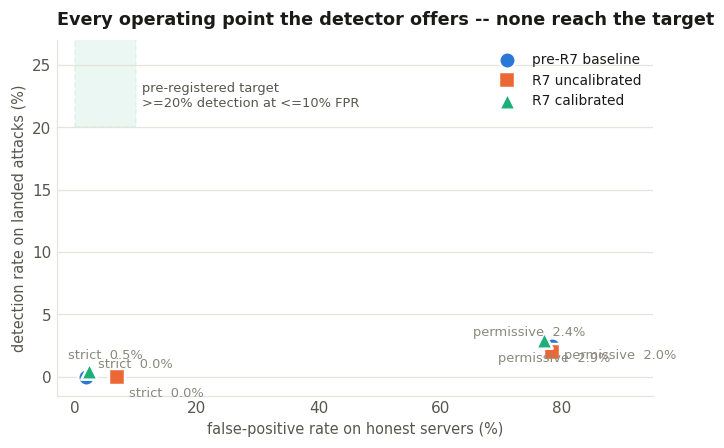

In [3]:
from matplotlib.patches import Rectangle
fig, ax = plt.subplots(figsize=(7.0, 4.2))
style = {"pre-R7 baseline": (BLUE, "o"), "R7 uncalibrated": (ORANGE, "s"),
         "R7 calibrated": (AQUA, "^")}

# The acceptance region, drawn once as a single rectangle rather than two
# overlapping half-plane spans (which produced a muddy third colour where
# they crossed and read as a category of its own).
ax.add_patch(Rectangle((0, 20), 10, 80, facecolor=AQUA, alpha=0.09,
                       edgecolor=AQUA, linewidth=1, linestyle="--", zorder=0))
ax.annotate("pre-registered target\n>=20% detection at <=10% FPR",
            (11, 21.4), fontsize=8.5, color=INK_2, va="bottom")

# Labels are offset per point instead of a fixed direction: the strict and
# permissive points of different runs land almost on top of each other, and
# one shared offset stacked the text illegibly.
offsets = {("pre-R7 baseline","strict"): (8, 6),
           ("R7 uncalibrated","strict"): (8, -13),
           ("R7 calibrated","strict"): (-14, 8),
           ("pre-R7 baseline","permissive"): (-52, 7),
           ("R7 uncalibrated","permissive"): (8, -4),
           ("R7 calibrated","permissive"): (-30, -14)}
seen = set()
for label, pname, n, landed, tp, det, fp, fpr in table:
    c, m = style[label]
    ax.scatter(100*fpr, 100*det, s=115, color=c, marker=m, zorder=3,
               edgecolor="white", linewidth=1.6,
               label=label if label not in seen else None)
    seen.add(label)
    ax.annotate(f"{pname}  {100*det:.1f}%", (100*fpr, 100*det),
                xytext=offsets[(label, pname)], textcoords="offset points",
                fontsize=8.5, color=MUTED, zorder=4)

ax.set_xlabel("false-positive rate on honest servers (%)")
ax.set_ylabel("detection rate on landed attacks (%)")
# Detection never exceeds ~3%, so the axis stops just above the 20% target
# line. Scaling to 100 would render every measurement as a dot on the floor.
ax.set_xlim(-3, 95); ax.set_ylim(-1.5, 27)
ax.set_title("Every operating point the detector offers -- none reach the target")
ax.legend(loc="upper right")
nbstyle.save(fig, "operating_points", RESULTS); plt.show()

## The detections the detector found and discarded

In [4]:
base = [r for r in load("pilot_pre_r7_baseline.json") if r.get("status")=="ok"]
def sev(a, k): return [x for x in a if x.startswith(f"[{k}]")]
for r in base:
    t = tampered(r)
    if not t.get("attack_landed"): continue
    if (not sev(honest(r),"VIOLATION") and not sev(t.get("alerts",[]),"VIOLATION")
            and not sev(honest(r),"WARNING") and sev(t.get("alerts",[]),"WARNING")):
        print(f"* {r['server_id']}   [{r.get('write_tool')} / "
              f"diverted: {t.get('diverted_field')}]")
        print(f"    {sev(t['alerts'],'WARNING')[0][:190]}\n")

* dev.useaxis/axis   [update_context / diverted: filename]
    [WARNING] update_context / R1: read_context reports the target of this write does not exist, yet the response claimed success (weak pairing: read_context shares only a resource noun with upd

* io.github.KVANTRA-dev/NOUZ-MCP   [write_file / diverted: path]
    [WARNING] write_file / R1: read_file reports the target of this write does not exist, yet the response claimed success (weak pairing: read_file shares only a resource noun with write_file, n

* io.github.Semiotronika/NOUZ-MCP   [write_file / diverted: path]
    [WARNING] write_file / R1: read_file reports the target of this write does not exist, yet the response claimed success (weak pairing: read_file shares only a resource noun with write_file, n

* io.github.domdomegg/filesystem-mcp   [create / diverted: path]
    [WARNING] create / R1: view reports the target of this write does not exist, yet the response claimed success (weak pairing: view shares only a resource 

These attacks landed, the tampered trial fired, and the honest trial did not. They are real catches that were reported as warnings and therefore scored zero.